
---

# 📊 **`Data Discretization in Python for Machine Learning in Data Science`**  

### ✅ **What is Data Discretization?**  
Data **discretization** is the process of converting **continuous numerical data** into **discrete categories or bins**. Many **Machine Learning (ML) algorithms**, such as **Decision Trees, Naïve Bayes, and Rule-Based Models**, perform better when working with **categorical features** rather than continuous ones.

### 📌 **Why is Data Discretization Important?**  
✔ **Reduces data complexity** → Makes models more interpretable.  
✔ **Handles outliers** → Reduces the impact of extreme values.  
✔ **Enhances model accuracy** → Useful for **tree-based models** (Decision Trees, Random Forest).  
✔ **Improves data compression** → Helps in feature reduction.  

---

## 🏷️ **1. Types of Data Discretization**  

| **Method**                | **Description**                             | **Use Case**                      |
|--------------------------|----------------------------------|--------------------------------|
| **Fixed-Width Binning**   | Divides data into equal-sized bins (e.g., Age 0-20, 20-40) | When we need equal range bins |
| **Quantile Binning**      | Divides data so that each bin has the same number of values | When data is skewed |
| **K-Means Binning**       | Uses K-Means clustering to group similar values | When natural groups exist |
| **Decision Tree Binning** | Uses Decision Tree to learn optimal bin boundaries | When data is complex |
| **Custom Binning**        | Manually defines bin ranges based on domain knowledge | When specific ranges are needed |

---

## 📏 **2. Fixed-Width Binning (Equal Interval Binning)**  

**✅ Best for:** Data with a **uniform distribution**.

### **🔢 Example: Age Binning**  


In [1]:

import numpy as np
import pandas as pd

# Sample Data
df = pd.DataFrame({'Age': [15, 22, 35, 42, 50, 67, 75]})

# Define Bins (0-20, 20-40, 40-60, etc.)
bins = [0, 20, 40, 60, 80]
labels = ['Teen', 'Young Adult', 'Adult', 'Senior']

# Apply Binning
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
print(df)

   Age    Age_Group
0   15         Teen
1   22  Young Adult
2   35  Young Adult
3   42        Adult
4   50        Adult
5   67       Senior
6   75       Senior


**🔹 Use When:** The **range of data is evenly distributed**.

---

## 📊 **3. Quantile-Based Binning (Equal Frequency Binning)**  

**✅ Best for:** Data that is **skewed** or **not evenly distributed**.

### **🔢 Example: Using `qcut()` for Equal Frequency Binning**  

In [2]:

# Apply Quantile Binning (Equal-Frequency Binning)
df['Age_Quantile'] = pd.qcut(df['Age'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(df)


   Age    Age_Group Age_Quantile
0   15         Teen           Q1
1   22  Young Adult           Q1
2   35  Young Adult           Q2
3   42        Adult           Q2
4   50        Adult           Q3
5   67       Senior           Q4
6   75       Senior           Q4



**🔹 Use When:** The **distribution is skewed**, and you want bins with **equal number of samples**.

---

## 🤖 **4. K-Means Clustering for Binning**  

**✅ Best for:** Finding **natural groupings** in data.

### **🔢 Example: Using K-Means for Data Discretization**  

In [3]:

from sklearn.cluster import KMeans

# Sample Data
data = np.array(df['Age']).reshape(-1, 1)

# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df['Age_Cluster'] = kmeans.fit_predict(data)

print(df)

   Age    Age_Group Age_Quantile  Age_Cluster
0   15         Teen           Q1            2
1   22  Young Adult           Q1            2
2   35  Young Adult           Q2            0
3   42        Adult           Q2            0
4   50        Adult           Q3            0
5   67       Senior           Q4            1
6   75       Senior           Q4            1




**🔹 Use When:** The data naturally groups into **clusters**.

---

## 🌲 **5. Decision Tree-Based Binning**  

**✅ Best for:** Data with complex patterns.  

### **🔢 Example: Using Decision Tree for Optimal Binning**  

In [4]:

from sklearn.tree import DecisionTreeClassifier

# Sample Data
X = df[['Age']]
y = [0, 0, 1, 1, 1, 2, 2]  # Fake target variable for classification

# Train Decision Tree Classifier
tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X, y)

# Find Optimal Bins
df['Age_TreeBinned'] = tree.apply(X)
print(df)

   Age    Age_Group Age_Quantile  Age_Cluster  Age_TreeBinned
0   15         Teen           Q1            2               1
1   22  Young Adult           Q1            2               1
2   35  Young Adult           Q2            0               3
3   42        Adult           Q2            0               3
4   50        Adult           Q3            0               3
5   67       Senior           Q4            1               4
6   75       Senior           Q4            1               4


**🔹 Use When:** The **binning should be data-driven**, based on feature importance.

---

## 🏷️ **6. Custom Binning (Using Domain Knowledge)**  

**✅ Best for:** Manually defining **specific bins** based on expert knowledge.

### **🔢 Example: Custom Binning**  


In [5]:

def custom_age_binning(age):
    if age < 18:
        return 'Child'
    elif age < 30:
        return 'Young Adult'
    elif age < 50:
        return 'Middle-Aged'
    else:
        return 'Senior'

df['Custom_Bins'] = df['Age'].apply(custom_age_binning)
print(df)

   Age    Age_Group Age_Quantile  Age_Cluster  Age_TreeBinned  Custom_Bins
0   15         Teen           Q1            2               1        Child
1   22  Young Adult           Q1            2               1  Young Adult
2   35  Young Adult           Q2            0               3  Middle-Aged
3   42        Adult           Q2            0               3  Middle-Aged
4   50        Adult           Q3            0               3       Senior
5   67       Senior           Q4            1               4       Senior
6   75       Senior           Q4            1               4       Senior



**🔹 Use When:** There is **domain expertise** to guide binning decisions.

---

## 🏹 **7. When to Use Each Binning Technique?**  

| **Scenario**                        | **Recommended Binning**         |
|--------------------------------------|--------------------------------|
| Data is **uniformly distributed**    | Fixed-Width Binning (Equal Interval) |
| Data is **skewed**                   | Quantile Binning (Equal Frequency) |
| Data has **natural clusters**        | K-Means Binning |
| Complex patterns exist                | Decision Tree Binning |
| Expert knowledge available           | Custom Binning |

---

## 🏆 **8. Final Thoughts**  

✔ **Data discretization simplifies numerical data, making it easier for ML models to learn patterns.**  
✔ **Use Fixed-Width Binning for uniform distributions** and **Quantile Binning for skewed data.**  
✔ **K-Means and Decision Tree binning** provide **data-driven** approaches.  
✔ **Custom binning is best when domain knowledge is available.**  

💡 **Pro Tip:** Always **visualize the bins using histograms** to ensure they make sense!


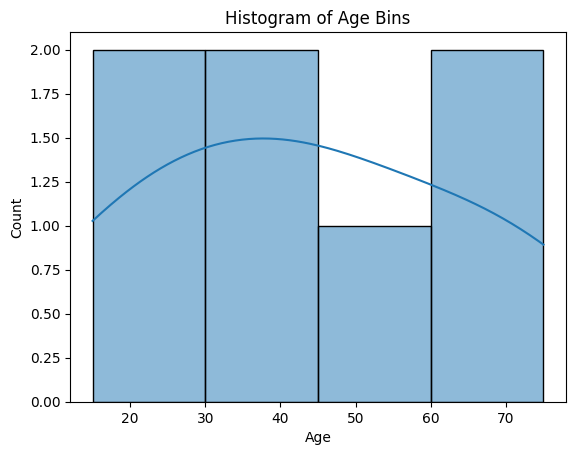

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Age'], bins=4, kde=True)
plt.title("Histogram of Age Bins")
plt.show()


---

## ***`Further Practice`***

In [8]:
# importing libraries
import os
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer

In [9]:
# load titanic data from seaborn
df = sns.load_dataset("titanic")
df.head() 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
# impute the missing values
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [13]:
# age discretization
age_discretizer = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform")
df['age_bins'] = age_discretizer.fit_transform(df[['age']])

df[["age", "age_bins"]].sample(10)

,age,age_bins
250,28.0,1.0
527,28.0,1.0
669,28.0,1.0
353,25.0,1.0
607,27.0,1.0
215,31.0,1.0
390,36.0,2.0
43,3.0,0.0
453,49.0,3.0
660,50.0,3.0


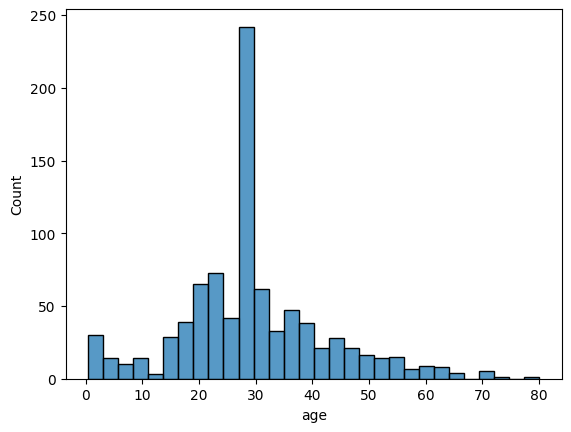

In [15]:
sns.histplot(df,x="age",)
plt.show()

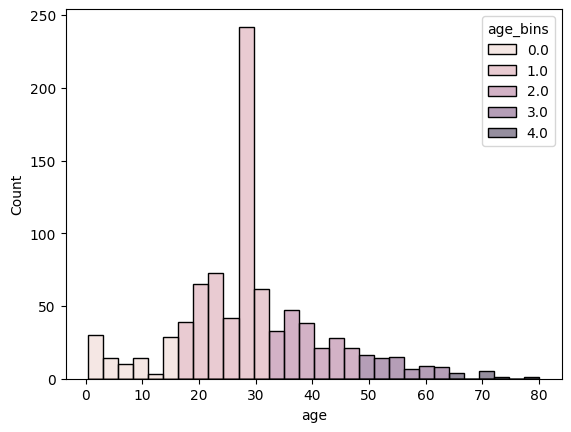

In [14]:
sns.histplot(df,x="age",hue="age_bins",)
plt.show()

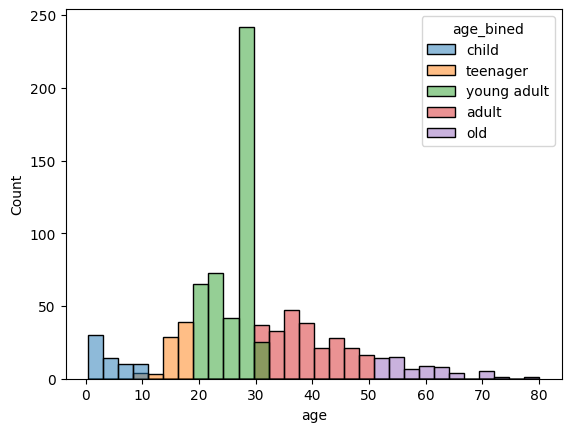

In [16]:
# define the bins
bins = [0,10,18,30,50,80]
labels = ['child','teenager','young adult','adult','old']
df['age_bined'] = pd.cut(df['age'],bins=bins,labels=labels)
sns.histplot(df,x="age",hue="age_bined")
plt.show()

---